# ETL

In [1]:
import requests
import json

api_url = "https://data.cincinnati-oh.gov/resource/2a8x-bxjm.json"

# Request up to 75,000 rows
params = {
    "$limit": 100000,
    "$order": "unique_work_order_no"
}

try:
    response = requests.get(api_url, params=params, timeout=60)
    response.raise_for_status()

    data = response.json()

    print(f"Data imported successfully. Rows returned: {len(data):,}")
    print("\nFirst 5 entries:")

    if isinstance(data, list) and len(data) > 0:
        for item in data[:5]:
            print(item)
    else:
        print("No data found or unexpected format.")

except requests.exceptions.RequestException as e:
    print(f"Error fetching data: {e}")
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Data imported successfully. Rows returned: 100,000

First 5 entries:
{'unique_work_order_no': '2007-2301-3108', 'create_date': '2008-01-01T00:00:00.000Z', 'loc_work_order_loc': '2301', 'loc_work_order_loc_name': 'WEST FORK', 'work_order_yr': '2007', 'work_order_no': '3108', 'job_type': 'PM', 'eq_equip_no': 'S11547A', 'work_order_status': 'CLOSED', 'meter_1_reading': '75145', 'datetime_out_service': '2008-01-01T00:00:00.000Z', 'datetime_in_service': '2008-01-04T00:00:00.000Z', 'datetime_open': '2008-01-01T00:00:00.000Z', 'datetime_first_labor': '2008-01-02T00:00:00.000Z', 'datetime_finished': '2008-01-04T00:00:00.000Z', 'datetime_closed': '2008-01-04T00:00:00.000Z', 'datetime_unit_in': '2008-01-01T00:00:00.000Z', 'datetime_due': '2008-01-04T00:00:00.000Z', 'datetime_pm_sched': '2007-11-05T00:00:00.000Z', 'qty_est_hours': '6.5', 'downtime_hrs_user': '0', 'downtime_hrs_shop': '9', 'warranty': 'NO', 'pri_priority_code': '3', 'dept_equip_dept': '0253', 'dept_equip_dept_name': 'NEIGHBORHOOD 

In [2]:
import pandas as pd

# Assuming 'data' is already available in the environment from the previous cell execution
if 'data' in locals() and isinstance(data, list):
    df = pd.DataFrame(data)
    print("Data successfully converted to a Pandas DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df.head())
else:
    print("Error: 'data' variable not found or is not a list. Please run the data import cell first.")

Data successfully converted to a Pandas DataFrame.
First 5 rows of the DataFrame:


,unique_work_order_no,create_date,loc_work_order_loc,loc_work_order_loc_name,work_order_yr,work_order_no,job_type,eq_equip_no,work_order_status,meter_1_reading,...,eq_parent_equip_no,delay_hours,labor_hours,labor_cost,parts_cost,comml_cost,total_cost,reas_reas_for_repair,reas_for_repair_desc,ref_work_order_no
0,2007-2301-3108,2008-01-01T00:00:00.000Z,2301,WEST FORK,2007,3108,PM,S11547A,CLOSED,75145,...,11547,0,6.5,409.5,415.57,0,825.07,NaN,NaN,NaN
1,2007-2301-3109,2008-01-01T00:00:00.000Z,2301,WEST FORK,2007,3109,REPAIR,S11547A,CLOSED,75145,...,11547,0,0.3,18.9,859.13,0,878.03,N,NORMAL WEAR (TARGET),NaN
2,2007-2302-1299,2008-01-01T00:00:00.000Z,2302,NEW HIGHWAY,2007,1299,REPAIR,S70995,CLOSED,24401,...,70995,0,0.5,31.5,12.79,0,44.29,N,NORMAL WEAR (TARGET),NaN
3,2007-2302-1300,2008-01-01T00:00:00.000Z,2302,NEW HIGHWAY,2007,1300,REPAIR,S00932,CLOSED,21104,...,00932,0,0.9,56.7,32.31,0,89.01,N,NORMAL WEAR (TARGET),NaN
4,2007-2302-1301,2008-01-01T00:00:00.000Z,2302,NEW HIGHWAY,2007,1301,REPAIR,S70947,CLOSED,66785,...,70947,0,0.9,56.7,31.69,0,88.39,N,NORMAL WEAR (TARGET),NaN


In [3]:
df.info()

print(f"\nRow count: {len(df)}")
print(f"Duplicate count: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   unique_work_order_no     100000 non-null  object
 1   create_date              100000 non-null  object
 2   loc_work_order_loc       100000 non-null  object
 3   loc_work_order_loc_name  100000 non-null  object
 4   work_order_yr            100000 non-null  object
 5   work_order_no            100000 non-null  object
 6   job_type                 100000 non-null  object
 7   eq_equip_no              100000 non-null  object
 8   work_order_status        100000 non-null  object
 9   meter_1_reading          100000 non-null  object
 10  datetime_out_service     100000 non-null  object
 11  datetime_in_service      99842 non-null   object
 12  datetime_open            99989 non-null   object
 13  datetime_first_labor     92216 non-null   object
 14  datetime_finished    

Missingness by job type

In [4]:
print(df['job_type'].unique())

['PM' 'REPAIR']


In [5]:
date_cols = [
    "datetime_in_service",
    "datetime_finished",
    "datetime_closed",
    "datetime_pm_sched",
    "datetime_first_labor"
]

missing_by_job = (
    df.groupby("job_type")[date_cols]
      .apply(lambda x: x.isna().mean() * 100)
      .round(1)
)

missing_by_job

,datetime_in_service,datetime_finished,datetime_closed,datetime_pm_sched,datetime_first_labor
job_type,,,,,
PM,0.6,0.0,0.0,0.0,0.2
REPAIR,0.0,0.0,0.0,100.0,10.2


# Reason for repair

In [6]:
print("Unique values for 'reas_reas_for_repair':")
print(df['reas_reas_for_repair'].unique())

print("\nUnique values for 'reas_for_repair_desc':")
print(df['reas_for_repair_desc'].unique())

Unique values for 'reas_reas_for_repair':
[nan 'N' 'D' 'R' 'O' 'W' 'A' 'Q' 'V' 'X' 'F' 'Z' 'L' 'M' 'T' 'I' 'P' 'J'
 'C' 'B' 'S']

Unique values for 'reas_for_repair_desc':
[nan 'NORMAL WEAR (TARGET)' 'DAMAGE IN OPERATION (NON TARGE'
 'ROAD CALL-TARGET' 'USER CAUSED-NON TARGET' 'WARRANTY (TARGET)'
 'ACCIDENT (NON TARGET)' 'MANAGEMENT REQUEST-NON TARGET'
 'VANDALISM-NON TARGET' 'REWORK (TARGET)' 'ROAD CALL-NON TARGET'
 'DISASTER RELATED (NON TARGET)' 'LANDFILL DAMAGE-NON TARGET'
 'MANUFACTURERS RECALL (TARGET)' 'PIS-RESTRICTED (TARGET)'
 'INSPECTION (TARGET)' 'ROADWORTHY INSPECT-NON TARGET'
 'PIS-GENERAL (TARGET)' 'CAPITAL (NON TARGET)'
 'BULK COLLECT DAMAGE (NONTARGET' 'SALE PREPARATION (TARGET)']


/tmp/ipykernel_11329/2601662290.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_reasons.index, y=top_10_reasons.values, palette='viridis')


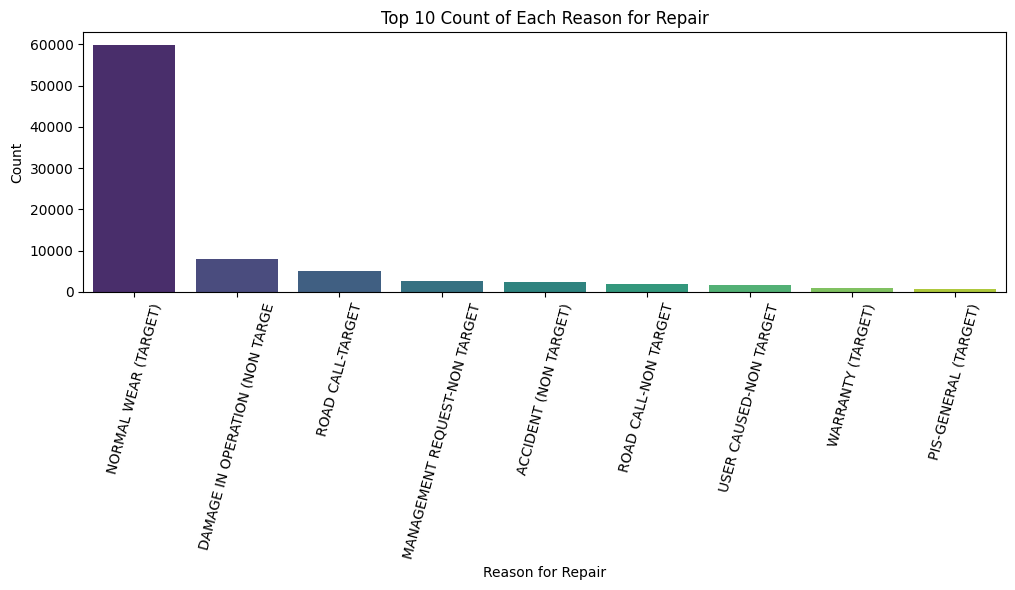

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each reason for repair, including NaN values
reason_counts = df['reas_for_repair_desc'].value_counts(dropna=False)

# Select the top 10 reasons for repair
top_10_reasons = reason_counts.head(10)

# Create the bar chart for the top 10 reasons
plt.figure(figsize=(10.26, 6))
sns.barplot(x=top_10_reasons.index, y=top_10_reasons.values, palette='viridis')
plt.title('Top 10 Count of Each Reason for Repair')
plt.xlabel('Reason for Repair')
plt.ylabel('Count')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11329/1288362730.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cost_by_reason.index, y=top_10_cost_by_reason.values, palette='magma')


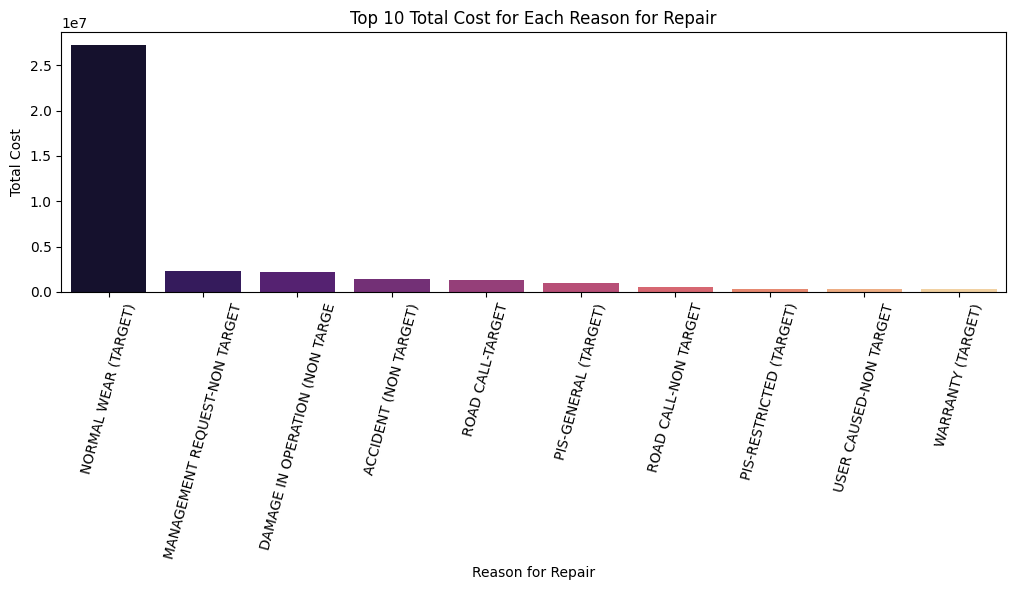

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'total_cost' is numeric
df['total_cost'] = pd.to_numeric(df['total_cost'], errors='coerce')

# Group by 'reas_for_repair_desc' and sum the 'total_cost'
cost_by_reason = df.groupby('reas_for_repair_desc')['total_cost'].sum().sort_values(ascending=False)

# Select the top 10 reasons for repair by total cost
top_10_cost_by_reason = cost_by_reason.head(10)

# Create the bar chart for the top 10 reasons
plt.figure(figsize=(10.26, 6))
sns.barplot(x=top_10_cost_by_reason.index, y=top_10_cost_by_reason.values, palette='magma')
plt.title('Top 10 Total Cost for Each Reason for Repair')
plt.xlabel('Reason for Repair')
plt.ylabel('Total Cost')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Downtime hours vs Cost relationship with PM Ratio

>PM Ratio = PM Count / Total work orders \
per equipment number

Downtime Hours (User) by Job Type:
  job_type  downtime_hrs_user
0       PM          85.104024
1   REPAIR         274.409485


/tmp/ipykernel_11329/2065166121.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='job_type', y='downtime_hrs_user', data=downtime_user_by_job_type, palette='coolwarm')


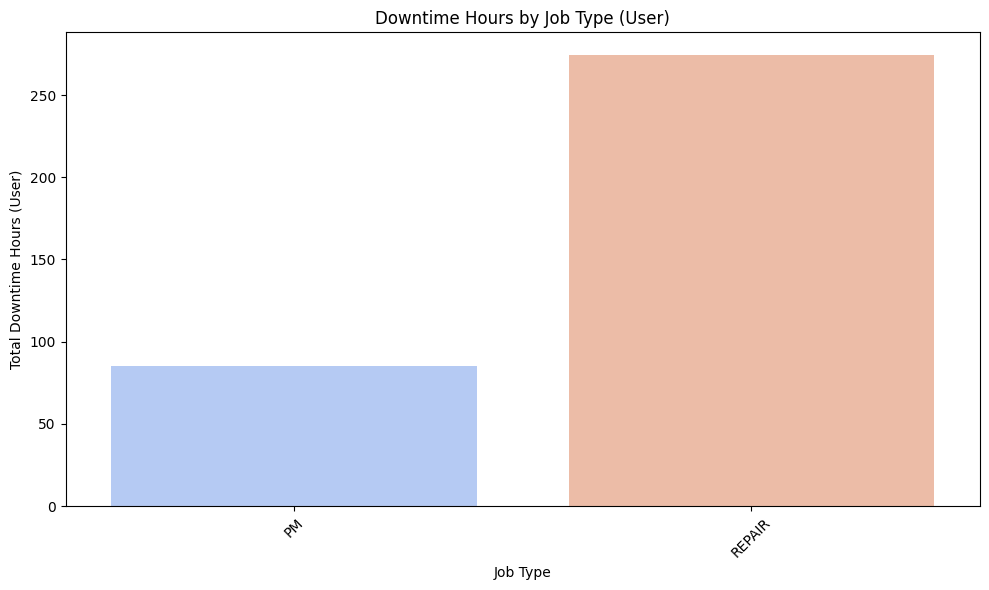

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'downtime_hrs_user' is numeric
df['downtime_hrs_user'] = pd.to_numeric(df['downtime_hrs_user'], errors='coerce').fillna(0)

# Group by job type and aggregate downtime_hrs_user
downtime_user_by_job_type = df.groupby('job_type')['downtime_hrs_user'].mean().reset_index()

print("Downtime Hours (User) by Job Type:")
print(downtime_user_by_job_type)

# Create a bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='job_type', y='downtime_hrs_user', data=downtime_user_by_job_type, palette='coolwarm')
plt.title('Downtime Hours by Job Type (User)')
plt.xlabel('Job Type')
plt.ylabel('Total Downtime Hours (User)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Downtime Hours (Shop) by Job Type:
  job_type  downtime_hrs_shop
0       PM          23.458277
1   REPAIR         137.077903


/tmp/ipykernel_11329/3127376693.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='job_type', y='downtime_hrs_shop', data=downtime_shop_by_job_type, palette='magma')


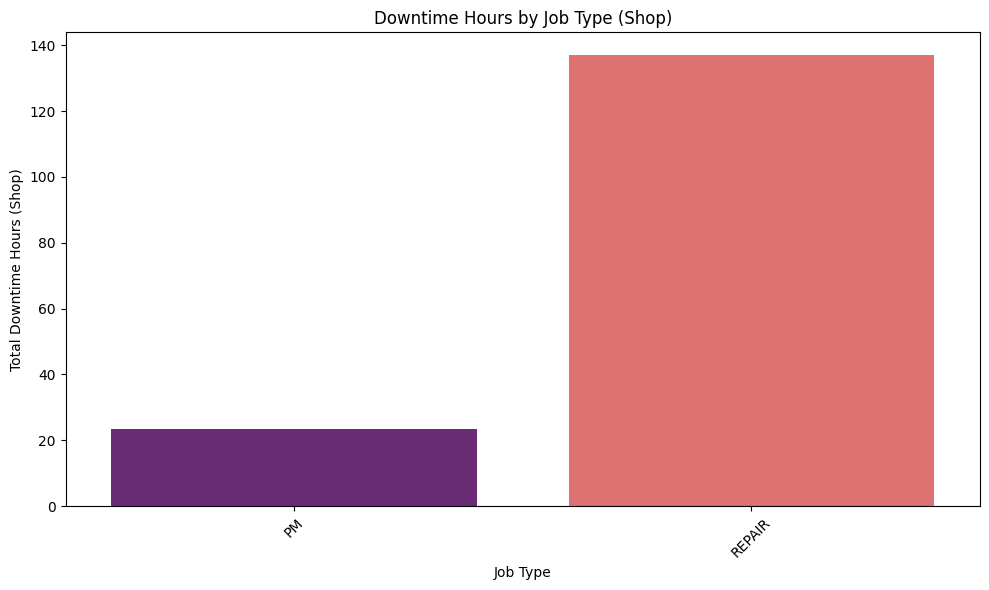

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'downtime_hrs_shop' is numeric
df['downtime_hrs_shop'] = pd.to_numeric(df['downtime_hrs_shop'], errors='coerce').fillna(0)

# Group by job type and aggregate downtime_hrs_shop
downtime_shop_by_job_type = df.groupby('job_type')['downtime_hrs_shop'].mean().reset_index()

print("Downtime Hours (Shop) by Job Type:")
print(downtime_shop_by_job_type)

# Create a bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='job_type', y='downtime_hrs_shop', data=downtime_shop_by_job_type, palette='magma')
plt.title('Downtime Hours by Job Type (Shop)')
plt.xlabel('Job Type')
plt.ylabel('Total Downtime Hours (Shop)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Preventive Maintenance (PM) jobs are overall less time consuming compared to repairs for both shops and users. Because PM and Repair jobs are not mutually exclusive, it does not prove that increasing PM reduces repairs.

What else can we do? Prove that increasing PM reduces repair costs and downtime

In [9]:
df['total_cost'] = pd.to_numeric(df['total_cost'], errors='coerce')
df['downtime_hrs_shop'] = pd.to_numeric(df['downtime_hrs_shop'], errors='coerce')

vehicle_summary = (
    df.groupby("eq_equip_no")
      .agg(
          total_work_orders=("unique_work_order_no", "nunique"),
          pm_count=("job_type", lambda x: (x == "PM").sum()),
          repair_count=("job_type", lambda x: (x == "REPAIR").sum()),
          total_repair_cost=("total_cost", lambda x: x[df.loc[x.index, "job_type"] == "REPAIR"].sum()),
          total_repair_downtime=("downtime_hrs_shop", lambda x: x[df.loc[x.index, "job_type"] == "REPAIR"].sum()),
          avg_meter=("meter_1_life_total", "max")
      )
      .reset_index()
)

vehicle_summary["pm_ratio"] = (
    vehicle_summary["pm_count"] / vehicle_summary["total_work_orders"]
)

vehicle_summary = vehicle_summary[
    vehicle_summary["total_work_orders"] >= 5
]

In [10]:
# PM BAND SUMMARY

vehicle_summary["pm_band"] = pd.cut(
    vehicle_summary["pm_ratio"],
    bins=[0, 0.2, 0.5, 1],
    labels=["Low PM", "Medium PM", "High PM"],
    include_lowest=True
)

pm_band_summary = (
    vehicle_summary.groupby("pm_band")
      .agg(
          vehicle_count=("eq_equip_no", "count"),
          avg_repair_cost=("total_repair_cost", "mean"),
          median_repair_cost=("total_repair_cost", "median"),
          avg_repair_downtime=("total_repair_downtime", "mean"),
          median_repair_downtime=("total_repair_downtime", "median"),
          avg_repair_count=("repair_count", "mean"),
          median_repair_count=("repair_count", "median")
      )
      .reset_index()
)

pm_band_summary

/tmp/ipykernel_11329/189354063.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vehicle_summary.groupby("pm_band")


,pm_band,vehicle_count,avg_repair_cost,median_repair_cost,avg_repair_downtime,median_repair_downtime,avg_repair_count,median_repair_count
0,Low PM,876,25632.179635,10555.45,3745.795285,2687.905,38.963470,29.0
1,Medium PM,1947,6636.515131,3937.81,3223.196595,2042.390,20.063688,13.0
2,High PM,304,1104.879013,718.40,1076.897303,367.640,3.717105,3.0


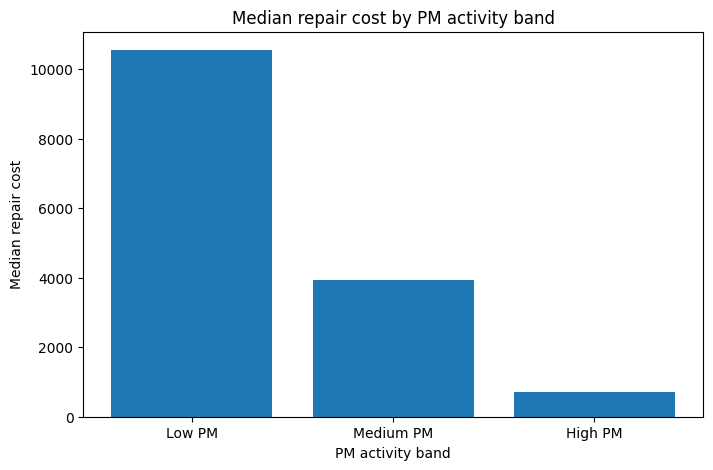

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(pm_band_summary["pm_band"], pm_band_summary["median_repair_cost"])
plt.title("Median repair cost by PM activity band")
plt.xlabel("PM activity band")
plt.ylabel("Median repair cost")
plt.show()

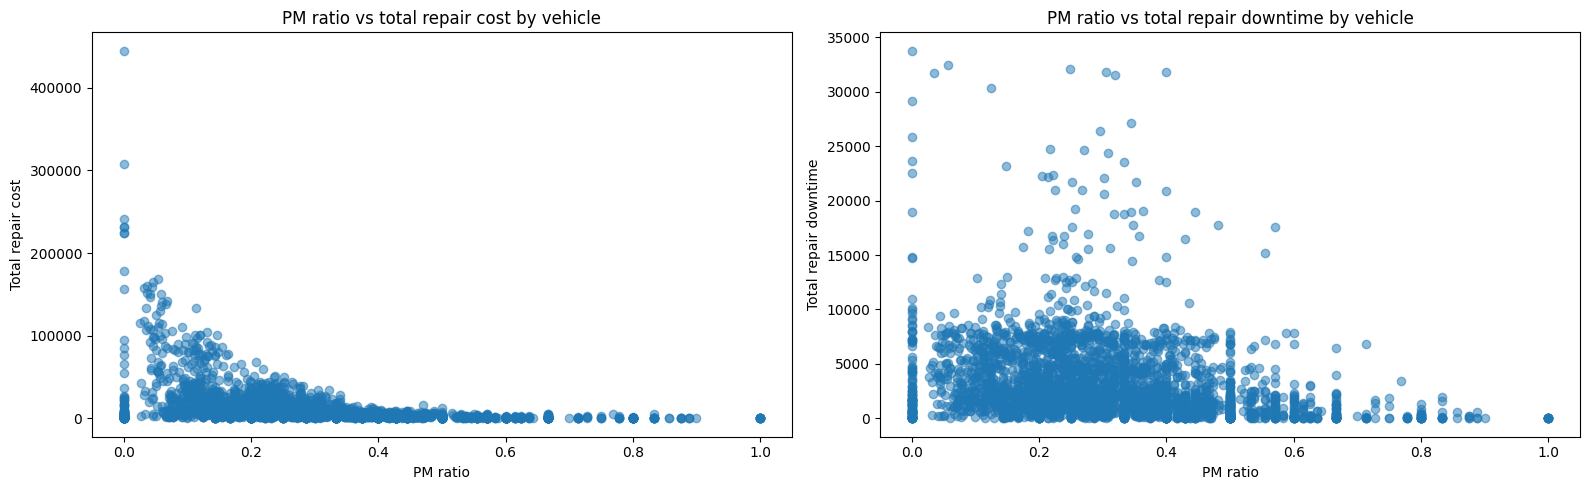

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5)) # Create a figure with two subplots

# Plot the first scatter plot on the first subplot
axes[0].scatter(
    vehicle_summary["pm_ratio"],
    vehicle_summary["total_repair_cost"],
    alpha=0.5
)
axes[0].set_xlabel("PM ratio")
axes[0].set_ylabel("Total repair cost")
axes[0].set_title("PM ratio vs total repair cost by vehicle")

# Plot the second scatter plot on the second subplot
axes[1].scatter(
    vehicle_summary["pm_ratio"],
    vehicle_summary["total_repair_downtime"],
    alpha=0.5
)
axes[1].set_xlabel("PM ratio")
axes[1].set_ylabel("Total repair downtime")
axes[1].set_title("PM ratio vs total repair downtime by vehicle")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

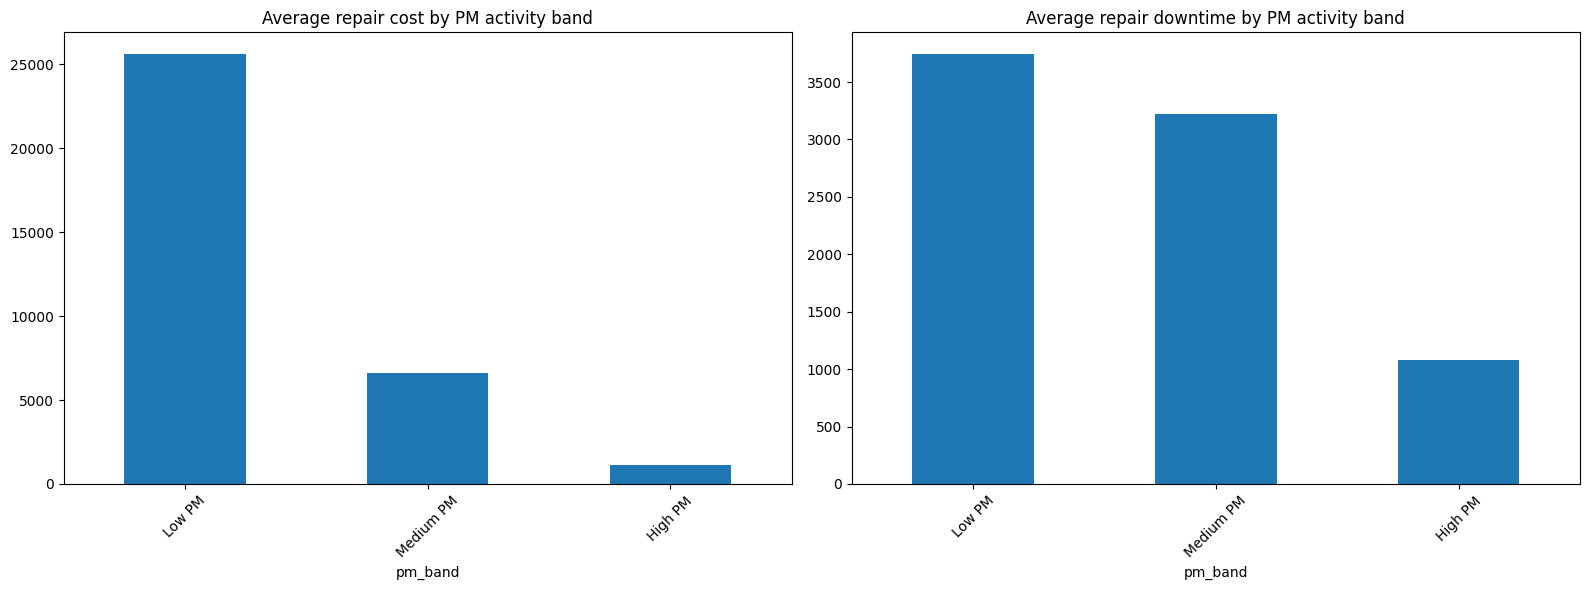

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pm_band_summary.plot(
    x="pm_band",
    y="avg_repair_cost",
    kind="bar",
    legend=False,
    title="Average repair cost by PM activity band",
    ax=axes[0]
)
axes[0].tick_params(axis='x', rotation=45)

pm_band_summary.plot(
    x="pm_band",
    y="avg_repair_downtime",
    kind="bar",
    legend=False,
    title="Average repair downtime by PM activity band",
    ax=axes[1]
)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

PM ratio and repair downtime have a weaker relationship to each other compared to PM ratio and repair costs. Repairs could be driven by unexpected accidents

# Vehicle Mileage

Normal wear per vehicle

In [18]:
normal_wear = df[df["reas_for_repair_desc"].str.contains("normal wear", case=False, na=False)]

normal_wear_vehicle = (
    normal_wear.groupby("eq_equip_no")
    .agg(
        normal_wear_count=("unique_work_order_no", "nunique"),
        normal_wear_cost=("total_cost", "sum"),
        normal_wear_downtime=("downtime_hrs_shop", "sum")
    )
    .sort_values("normal_wear_cost", ascending=False)
    .head(10)
)

normal_wear_vehicle

,normal_wear_count,normal_wear_cost,normal_wear_downtime
eq_equip_no,,,
07550,106,229994.52,25845.13
X2444,16,161704.99,557.90
X2441,65,155915.39,11748.97
91650,33,149464.17,2138.90
S61651,35,134441.62,2423.55
01651,33,132404.75,1562.79
DE31688,36,128155.22,3354.10
81651,38,127972.69,3658.03
31685,23,126373.10,3.29


In [19]:
normal_wear_dept = (
    normal_wear.groupby("dept_equip_dept_name")
    .agg(
        work_orders=("unique_work_order_no", "nunique"),
        total_cost=("total_cost", "sum"),
        avg_cost=("total_cost", "mean"),
        downtime=("downtime_hrs_shop", "sum")
    )
    .sort_values("total_cost", ascending=False)
    .head(10)
)

normal_wear_dept

,work_orders,total_cost,avg_cost,downtime
dept_equip_dept_name,,,,
FIRE DEPARTMENT RESPONSE,4134,5953738.74,1440.188374,483460.59
POLICE,22590,5945242.02,263.180258,2827371.41
NEIGHBORHOOD OPERATIONS,7485,5016036.77,670.145193,586869.99
TRAFFIC AND ROAD DIV,6049,3221224.89,532.521886,712374.22
M.S.D.,6765,2270606.62,335.640299,986865.90
WATER WORKS,4773,1327800.79,278.189983,412326.20
RECREATION,3504,1142246.40,325.983562,424996.68
FLEET SERVICES,446,605831.93,1358.367556,166360.45
PARK DEPARTMENT,1238,557952.61,450.688700,185884.06


<Axes: title={'center': 'Vehicle usage vs normal-wear repair cost'}, xlabel='max_meter', ylabel='normal_wear_cost'>

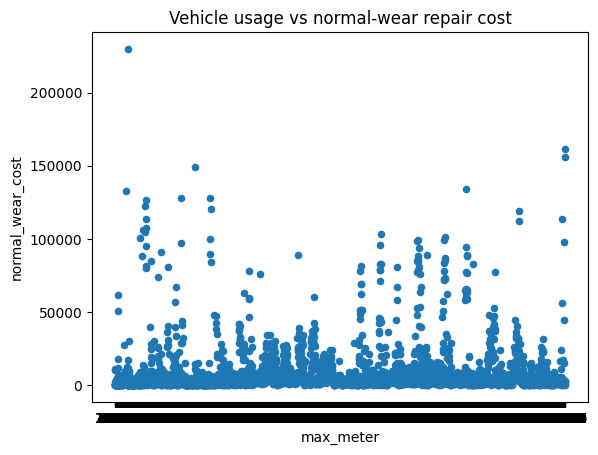

In [20]:
normal_wear_usage = (
    normal_wear.groupby("eq_equip_no")
    .agg(
        normal_wear_cost=("total_cost", "sum"),
        normal_wear_count=("unique_work_order_no", "nunique"),
        max_meter=("meter_1_life_total", "max")
    )
    .reset_index()
)

normal_wear_usage.plot(
    x="max_meter",
    y="normal_wear_cost",
    kind="scatter",
    title="Vehicle usage vs normal-wear repair cost"
)

In [23]:
normal_wear_usage['max_meter'] = pd.to_numeric(normal_wear_usage['max_meter'], errors='coerce')
normal_wear_usage["usage_band"] = pd.qcut(
    normal_wear_usage["max_meter"].dropna(), # Drop NaNs before qcut, as qcut does not handle them by default
    q=4,
    labels=["Low usage", "Medium-low usage", "Medium-high usage", "High usage"]
)

usage_band_summary = (
    normal_wear_usage.groupby("usage_band")
    .agg(
        vehicle_count=("eq_equip_no", "count"),
        avg_normal_wear_cost=("normal_wear_cost", "mean"),
        median_normal_wear_cost=("normal_wear_cost", "median"),
        avg_normal_wear_count=("normal_wear_count", "mean")
    )
    .reset_index()
)

usage_band_summary

/tmp/ipykernel_11329/3412190793.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  normal_wear_usage.groupby("usage_band")


,usage_band,vehicle_count,avg_normal_wear_cost,median_normal_wear_cost,avg_normal_wear_count
0,Low usage,965,1105.867047,235.30,3.525389
1,Medium-low usage,965,4868.008984,2023.94,13.529534
2,Medium-high usage,964,7735.822822,2836.93,14.778008
3,High usage,965,14545.599036,5426.59,30.296373


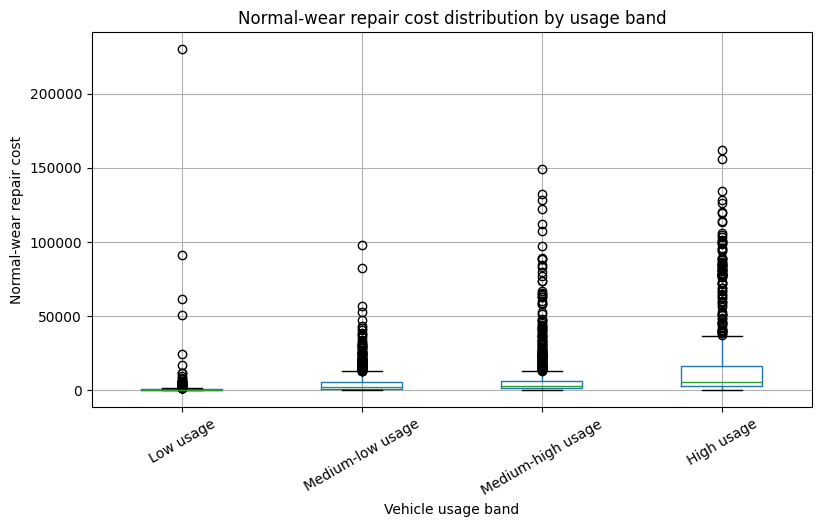

In [24]:
normal_wear_usage.boxplot(
    column="normal_wear_cost",
    by="usage_band",
    figsize=(9, 5)
)

plt.title("Normal-wear repair cost distribution by usage band")
plt.suptitle("")
plt.xlabel("Vehicle usage band")
plt.ylabel("Normal-wear repair cost")
plt.xticks(rotation=30)
plt.show()

## Cost per usage

In [25]:
normal_wear_usage = normal_wear_usage[
    normal_wear_usage["max_meter"] > 0
].copy()

normal_wear_usage["normal_wear_cost_per_10k_meter"] = (
    normal_wear_usage["normal_wear_cost"] / normal_wear_usage["max_meter"] * 10000
)

In [26]:
high_cost_per_usage = (
    normal_wear_usage.sort_values(
        "normal_wear_cost_per_10k_meter",
        ascending=False
    )
    .head(10)
)

high_cost_per_usage

,eq_equip_no,normal_wear_cost,normal_wear_count,max_meter,usage_band,normal_wear_cost_per_10k_meter
122,07550,229994.52,106,1,Low usage,2.299945e+09
2416,S4101,16741.09,7,1,Low usage,1.674109e+08
2141,S2301,11445.52,5,1,Low usage,1.144552e+08
3848,X0442,91043.99,54,8,Low usage,1.138050e+08
2314,S37483,9357.70,17,1,Low usage,9.357700e+07
3840,X0271,24054.38,35,3,Low usage,8.018127e+07
2913,S63652,5541.27,10,1,Low usage,5.541270e+07
2912,S63651,5293.94,9,1,Low usage,5.293940e+07
2415,S4100,7596.36,7,2,Low usage,3.798180e+07
2321,S3902,2872.21,7,1,Low usage,2.872210e+07


Vehicle usage alone does not account for total cost of maintenance. Specific vehicles have significantly higher cost per repair band, with a large number as outliers, which means specific vehicles should be flagged for maintenance inspection for parts replacement, vehicle replacement, maintenance plan reviews, etc.